In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [2]:
np.random.seed(613)
x1 = np.arange(50)
y1 = np.random.randint(0, 75,50)
x2 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y2 = np.array([110, 180, 240, 99, 220])

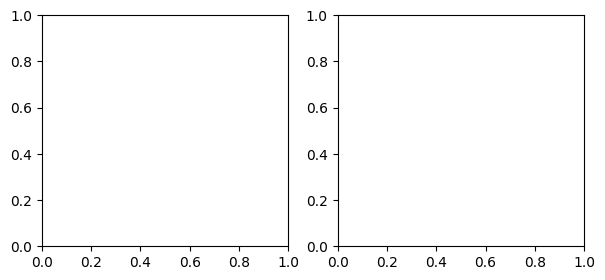

In [4]:
# we want to have two plots next to each other, so we just have to define multipleaxes and their relative positions:

fig,(ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(7, 3))

/var/folders/rz/q_ycy8wn56v66xqgsjqcc7540000gn/T/ipykernel_5980/209339063.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


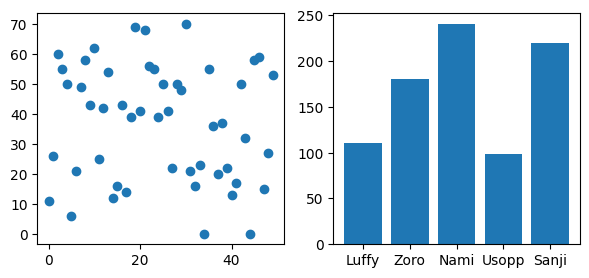

In [6]:
# Then we can use our new figure, with its two axes, and define the types of viz that wewant to see in each axis:
fig,(ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(7, 3))
ax1.scatter(x1, y1)
ax2.bar(x2, y2) 
fig.show()

/var/folders/rz/q_ycy8wn56v66xqgsjqcc7540000gn/T/ipykernel_5980/1866842357.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


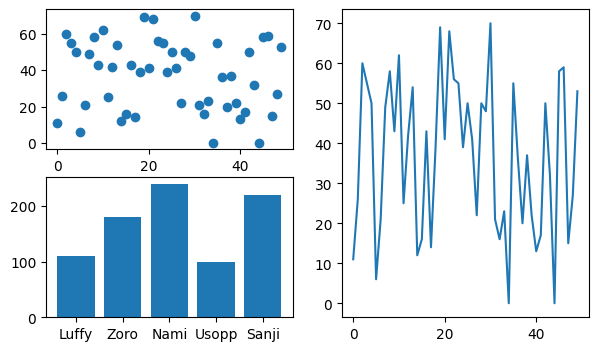

In [8]:
# We can also arrange the subplots within our figure by using plt.subplot_mosaic()
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'], 
                                    ['ax2', 'ax3']], 
                                    figsize=(7, 4))
someaxes['ax1'].scatter(x1, y1)
someaxes['ax2'].bar(x2, y2)
someaxes['ax3'].plot(y1)
fig.show()

Text(0.5, 0.98, 'My Very Large Title')

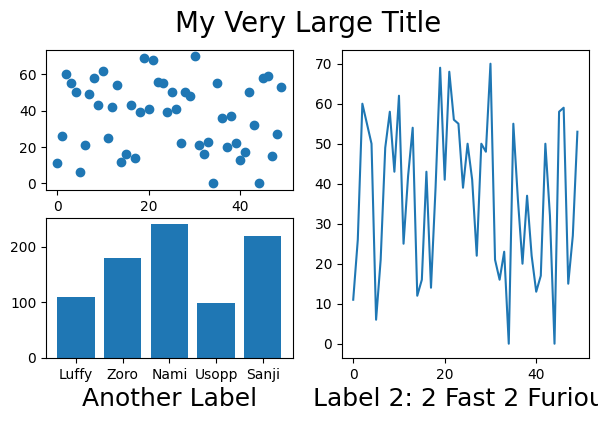

In [9]:
# Add Very large title to the figure
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'], ['ax2', 'ax3']], figsize=(7, 4)) 
someaxes["ax1"].scatter(x1,y1)
someaxes["ax2"].bar(x2,y2)
someaxes["ax3"].plot(x1,y1)
someaxes["ax1"].set_xlabel('A Big Label',fontsize=18)
someaxes["ax2"].set_xlabel('Another Label',fontsize=18)
someaxes["ax3"].set_xlabel('Label 2: 2 Fast 2 Furious',fontsize=18 )
fig.suptitle("My Very Large Title", fontsize=20)

Text(0.5, 0.98, 'My Very Large Title')

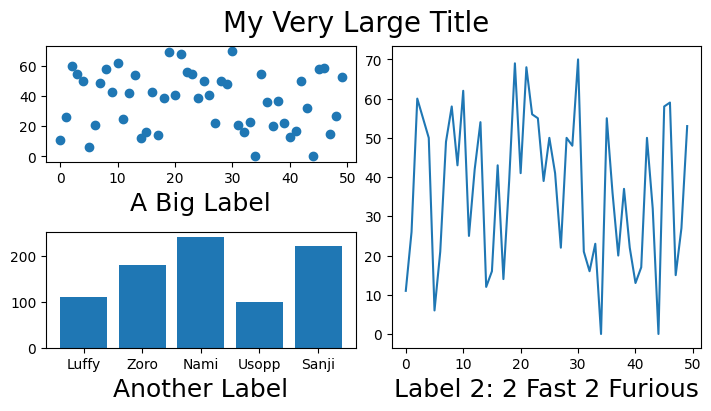

In [10]:
# Constrained Layout
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'], ['ax2', 'ax3']], figsize=(7, 4), constrained_layout=True) 
someaxes["ax1"].scatter(x1,y1)
someaxes["ax2"].bar(x2,y2)
someaxes["ax3"].plot(x1,y1)
someaxes["ax1"].set_xlabel('A Big Label',fontsize=18)
someaxes["ax2"].set_xlabel('Another Label',fontsize=18)
someaxes["ax3"].set_xlabel('Label 2: 2 Fast 2 Furious',fontsize=18 )
fig.suptitle("My Very Large Title", fontsize=20)

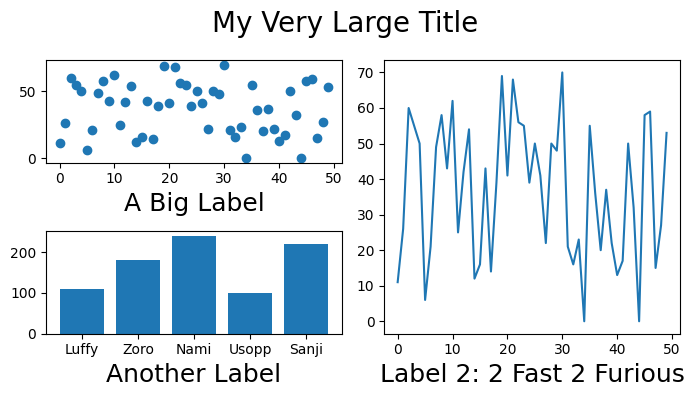

In [11]:
# Tight Layout
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'], ['ax2', 'ax3']], figsize=(7, 4)) 
someaxes["ax1"].scatter(x1,y1)
someaxes["ax2"].bar(x2,y2)
someaxes["ax3"].plot(x1,y1)
someaxes["ax1"].set_xlabel('A Big Label',fontsize=18)
someaxes["ax2"].set_xlabel('Another Label',fontsize=18)
someaxes["ax3"].set_xlabel('Label 2: 2 Fast 2 Furious',fontsize=18 )
fig.suptitle("My Very Large Title", fontsize=20)
fig.tight_layout()  

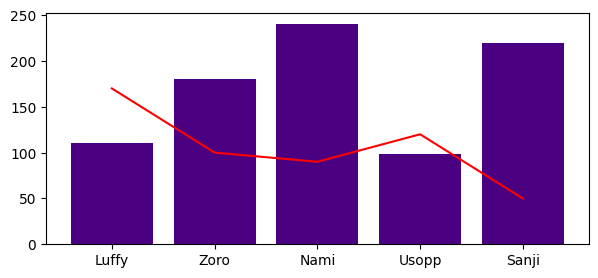

In [13]:
# Multiple viz on one axes object

# first make our sample data
x = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])
y2 = np.array([170, 100, 90, 120, 50])

# define our figure and axes (just one this time)
fig, ax = plt.subplots(figsize=(7, 3))

# now call both bar and plot elements to the same axes (ax)
ax.bar(x, y1,color = "indigo")
ax.plot(x, y2,color = "red")


<ErrorbarContainer object of 3 artists>

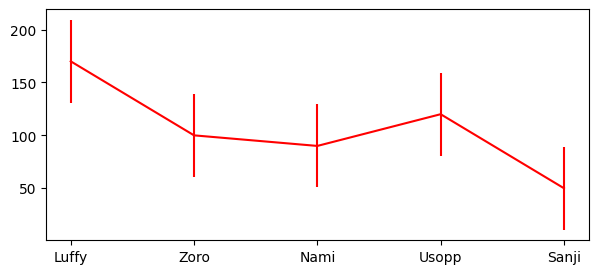

In [18]:
# Add error information
#calculate standard deviation of our data

y2_std = np.std(y2)

# Plot our lines
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2,color = "red")

# Then use errorbar() to add in our error line (standard deviation in this case, but couldbe whatever value you calculated)
# yerr specifies that we’re plotting vertical error bars
# fmt makes sure we’re not plotting the actual data points, only the error

ax.errorbar(x, y2, yerr=y2_std, fmt='none', color='red')


22

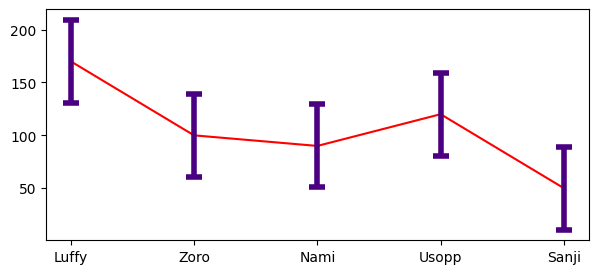

In [19]:
# Customizing errorbar appearance
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2, color = "red")
ax.errorbar(x, y2, yerr = y2_std, fmt = "none", ecolor= "indigo", elinewidth= 4, capsize = 6, capthick= 4 )
22


In [20]:
# If we don’t want to see error bars for every single point, we can specify intervals using errorevery
ax.errorbar(x, 
            y2, 
            yerr = y2_std, 
            fmt = "none", 
            ecolor= "indigo", 
            elinewidth= 4, 
            capsize = 6, 
            capthick= 4, 
            errorevery=2)

<ErrorbarContainer object of 3 artists>

(np.float64(-0.5), np.float64(219.5), np.float64(425.5), np.float64(-0.5))

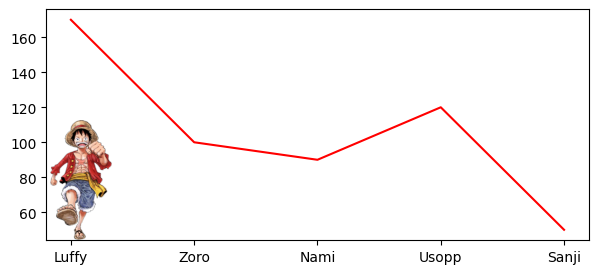

In [27]:
#Using images from the internet
from PIL import Image    # to open images
from io import BytesIO  # to store images

# get our image from the internet (some hosts block non-browser requests -> set User-Agent)
url = 'https://upload.wikimedia.org/wikipedia/en/c/cb/Monkey_D_Luffy.png'
resp = requests.get(url, headers=headers)
resp.raise_for_status()
image_file = BytesIO(resp.content)
image = Image.open(image_file)


#make a basic line plot (reusing our data)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2, color = 'red')

# overlay a new axis ('ax_image') on our figure (on top of 'ax') to act as a container for our image
ax_image = fig.add_axes([0.1, 0.11, 0.15, 0.4]) # [left, bottom, width, height]
ax_image.imshow(image) # add our image to the new axis
ax_image.axis('off') # turn off the axis lines and labels for the image